In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Columns

- id: The date and time of the measurement, in Central European Time (CET).
- valeur_CO: Measured concentration of Carbon Monoxide in milligrams per cubic meter (mg/m³).
- valeur_NO2: Measured concentration of Nitrogen Dioxide in micrograms per cubic meter (µg/m³).
- valeur_O3: Measured concentration of Ozone in micrograms per cubic meter (µg/m³).
- valeur_PM10: Measured concentration of Particulate Matter 10 micrometers or less in diameter in micrograms per cubic meter (µg/m³).
- valeur_PM25: Measured concentration of Particulate Matter 2.5 micrometers or less in diameter in micrograms per cubic meter (µg/m³).


In [4]:
df = pd.read_csv("data/train.csv")
df['id'] = pd.to_datetime(df['id'])
df = df.set_index('id')
df.head(-5)

,valeur_NO2,valeur_CO,valeur_O3,valeur_PM10,valeur_PM25
id,,,,,
2020-01-01 00:00:00,42.9,0.718,15.7,73.1,64.4
2020-01-01 01:00:00,33.6,0.587,10.1,74.8,66.0
2020-01-01 02:00:00,29.3,NaN,5.1,51.0,44.9
2020-01-01 03:00:00,30.5,0.246,7.2,27.7,25.1
2020-01-01 04:00:00,29.3,0.204,8.3,15.3,13.6
...,...,...,...,...,...
2024-09-03 13:00:00,NaN,0.170,63.0,10.0,3.5
2024-09-03 14:00:00,NaN,0.172,66.4,9.2,3.6
2024-09-03 15:00:00,NaN,0.177,67.9,10.9,3.9


The data goes in a one hour tact between 01.01.2020 and 03.09.2024 thus giving us **40k** rows

## Looking at the data

### Daily average per pollutant

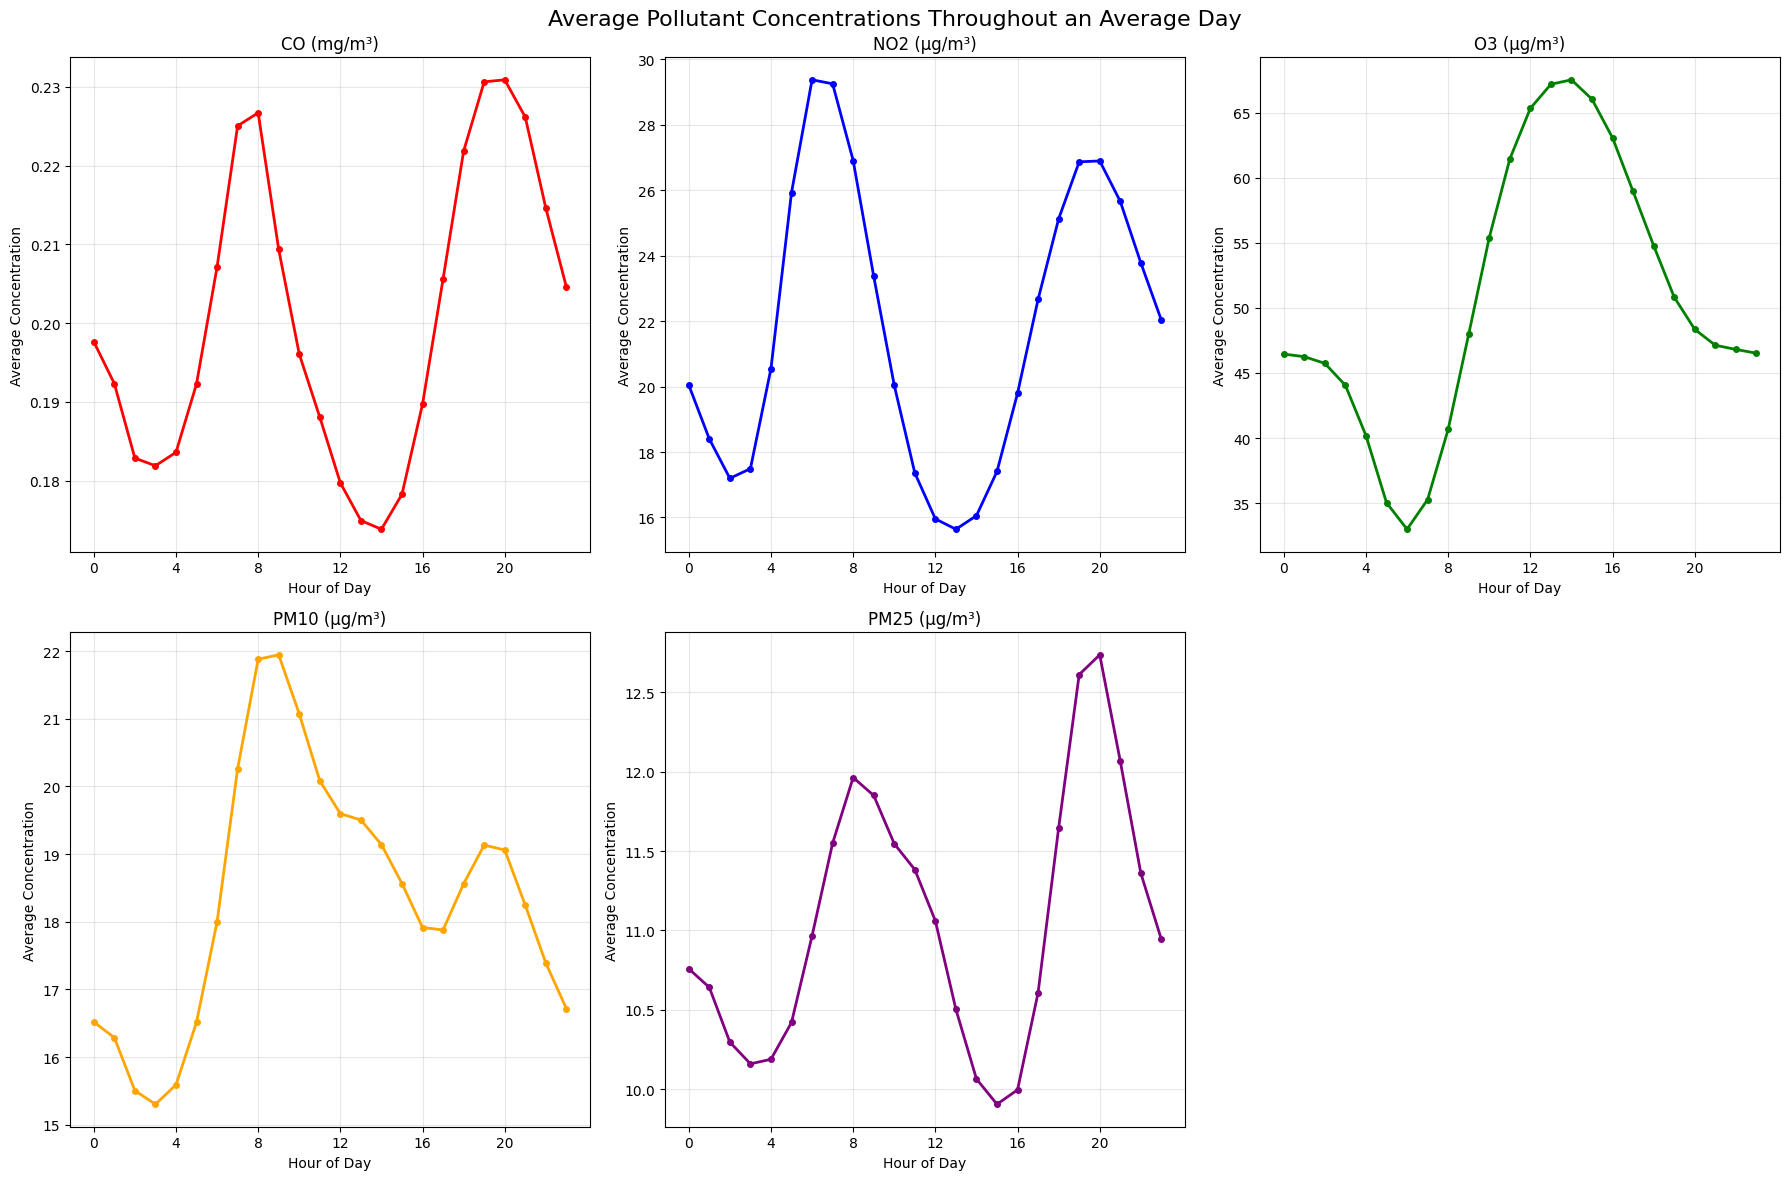

Daily Pattern Summary:
valeur_CO: Peak at 20:00 (0.23), Low at 14:00 (0.17)
valeur_NO2: Peak at 6:00 (29.38), Low at 13:00 (15.64)
valeur_O3: Peak at 14:00 (67.51), Low at 6:00 (33.00)
valeur_PM10: Peak at 9:00 (21.94), Low at 3:00 (15.30)
valeur_PM25: Peak at 20:00 (12.74), Low at 15:00 (9.91)


In [5]:
# Set up the pollutant columns
pollutant_columns = ['valeur_CO', 'valeur_NO2', 'valeur_O3', 'valeur_PM10', 'valeur_PM25']

# Create figure with 5 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Average Pollutant Concentrations Throughout an Average Day', fontsize=16)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Colors for each pollutant
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, (col, color) in enumerate(zip(pollutant_columns, colors)):
    # Calculate hourly averages for this pollutant, handling NaN values
    hourly_avg = df[col].groupby(df.index.hour).mean()
    
    # Plot
    axes_flat[i].plot(hourly_avg.index, hourly_avg.values, 
                     marker='o', linewidth=2, markersize=4, color=color)
    axes_flat[i].set_title(f'{col.replace("valeur_", "").upper()} (mg/m³)' if col == 'valeur_CO' 
                           else f'{col.replace("valeur_", "").upper()} (µg/m³)', fontsize=12)
    axes_flat[i].set_xlabel('Hour of Day')
    axes_flat[i].set_ylabel('Average Concentration')
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_xticks(range(0, 24, 4))  # Show every 4 hours

# Hide the 6th subplot (we only have 5 pollutants)
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()

# Print some summary statistics for the daily patterns
print("Daily Pattern Summary:")
for col in pollutant_columns:
    hourly_avg = df[col].groupby(df.index.hour).mean()
    max_hour = hourly_avg.idxmax()
    min_hour = hourly_avg.idxmin()
    print(f"{col}: Peak at {max_hour}:00 ({hourly_avg.max():.2f}), Low at {min_hour}:00 ({hourly_avg.min():.2f})")

### Weekly average per pollutant

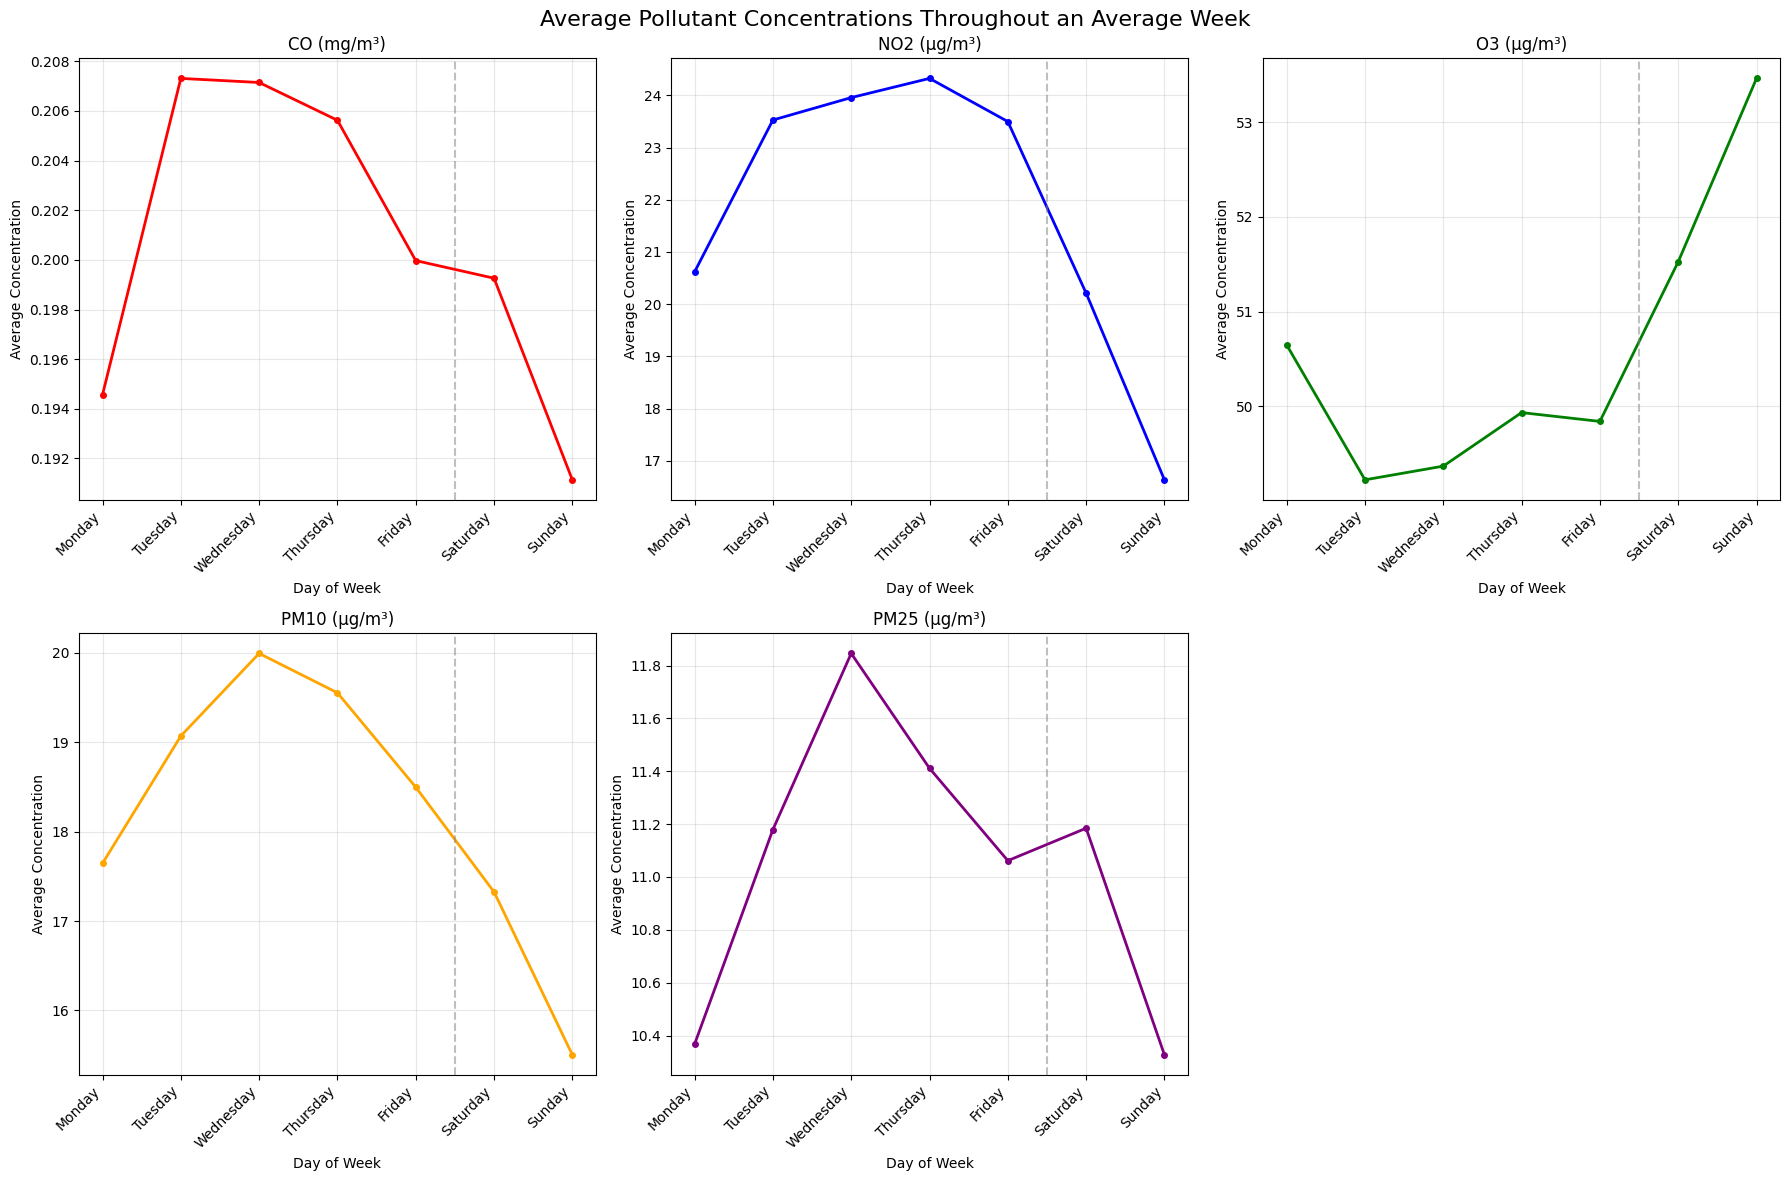

Weekly Pattern Summary:
valeur_CO: Peak on Tuesday (0.21), Low on Sunday (0.19)
valeur_NO2: Peak on Thursday (24.32), Low on Sunday (16.63)
valeur_O3: Peak on Sunday (53.46), Low on Tuesday (49.22)
valeur_PM10: Peak on Wednesday (19.99), Low on Sunday (15.50)
valeur_PM25: Peak on Wednesday (11.85), Low on Sunday (10.33)


In [6]:
# Create figure with 5 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Average Pollutant Concentrations Throughout an Average Week', fontsize=16)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Day names for better labels
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Colors for each pollutant (same as before)
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, (col, color) in enumerate(zip(pollutant_columns, colors)):
    # Calculate daily averages for this pollutant, handling NaN values
    daily_avg = df[col].groupby(df.index.dayofweek).mean()
    
    # Plot
    axes_flat[i].plot(daily_avg.index, daily_avg.values, 
                     marker='o', linewidth=2, markersize=4, color=color)
    axes_flat[i].set_title(f'{col.replace("valeur_", "").upper()} (mg/m³)' if col == 'valeur_CO' 
                           else f'{col.replace("valeur_", "").upper()} (µg/m³)', fontsize=12)
    axes_flat[i].set_xlabel('Day of Week')
    axes_flat[i].set_ylabel('Average Concentration')
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_xticks(range(7))
    axes_flat[i].set_xticklabels(day_names, rotation=45, ha='right')
    
    # Add a light vertical line to separate weekdays from weekend
    axes_flat[i].axvline(x=4.5, color='gray', linestyle='--', alpha=0.5, label='Weekend starts')

# Hide the 6th subplot (we only have 5 pollutants)
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()

# Print some summary statistics for the weekly patterns
print("Weekly Pattern Summary:")
for col in pollutant_columns:
    daily_avg = df[col].groupby(df.index.dayofweek).mean()
    max_day = daily_avg.idxmax()
    min_day = daily_avg.idxmin()
    print(f"{col}: Peak on {day_names[max_day]} ({daily_avg.max():.2f}), Low on {day_names[min_day]} ({daily_avg.min():.2f})")

### Yearly average per pollutant

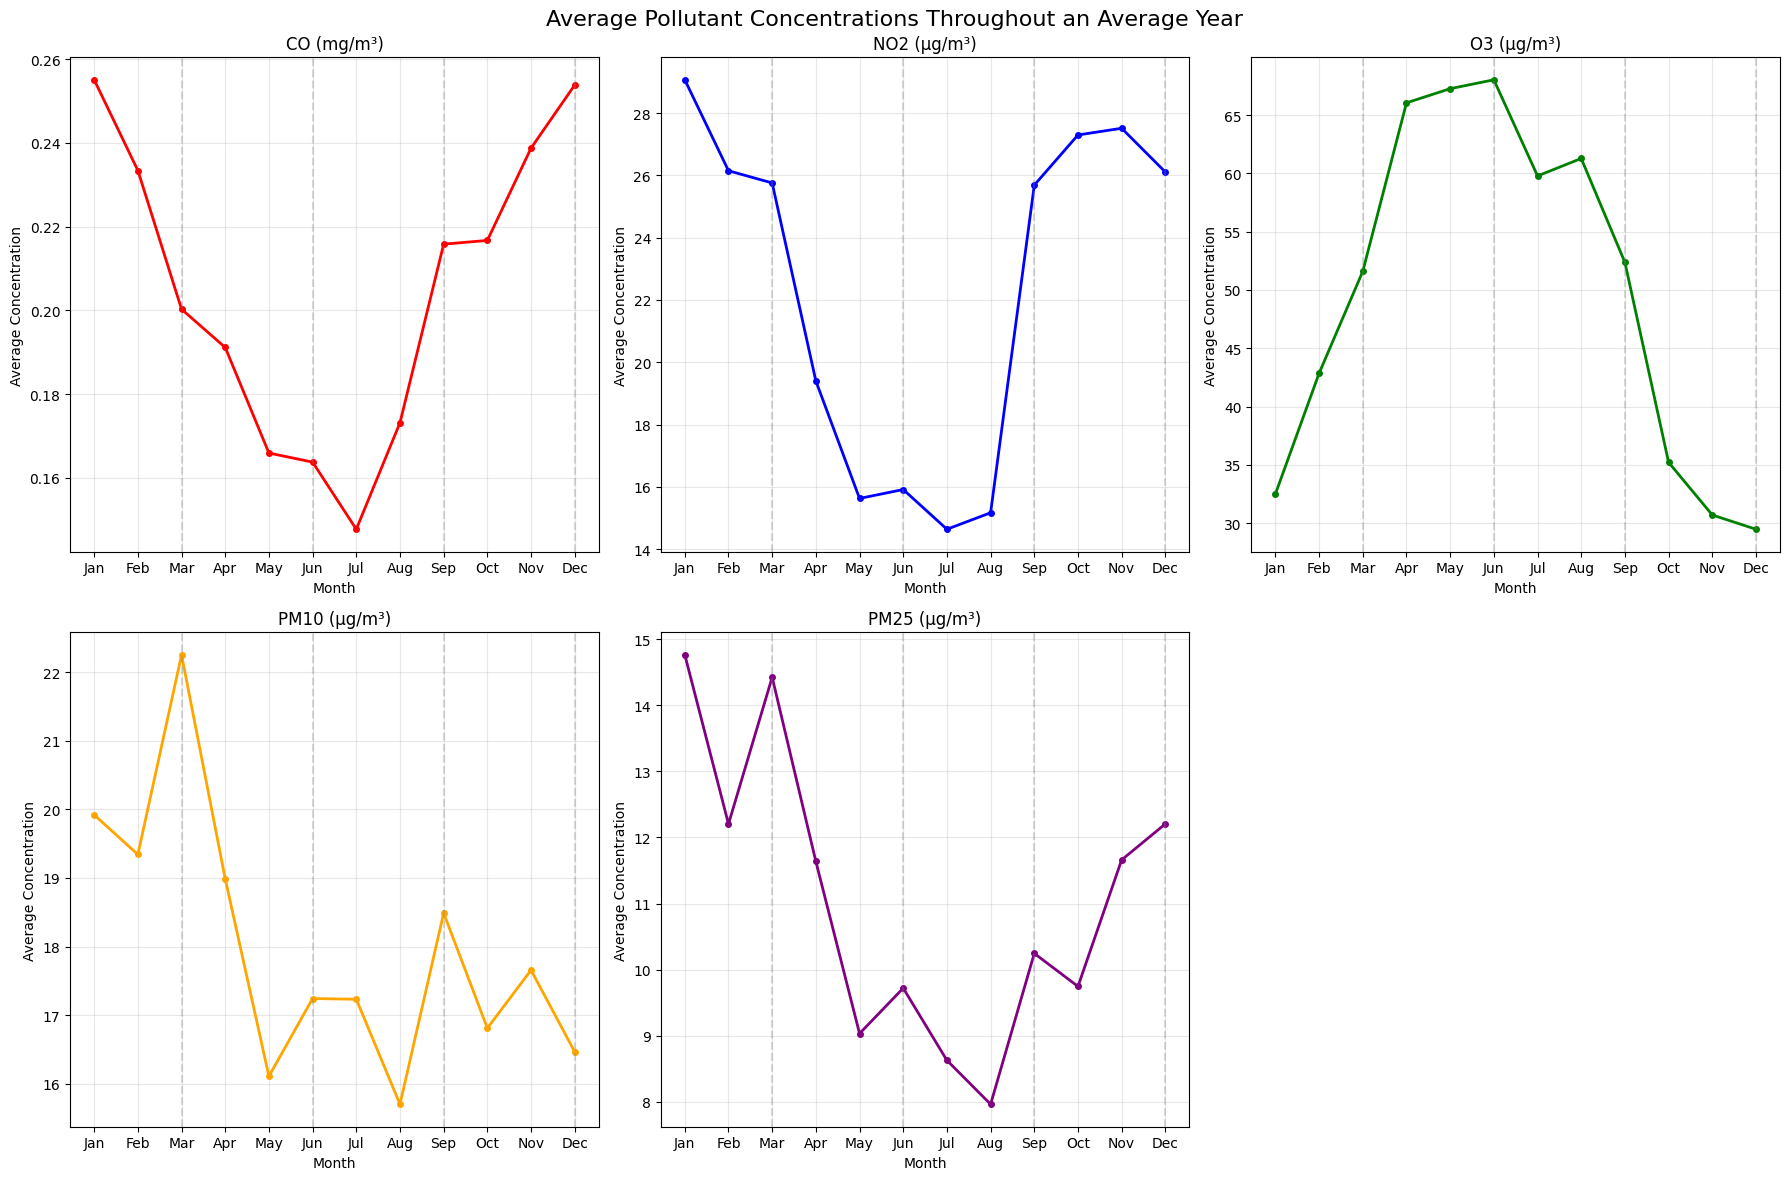

Yearly Pattern Summary:
valeur_CO: Peak in Jan (0.26), Low in Jul (0.15)
valeur_NO2: Peak in Jan (29.07), Low in Jul (14.64)
valeur_O3: Peak in Jun (68.03), Low in Dec (29.47)
valeur_PM10: Peak in Mar (22.25), Low in Aug (15.70)
valeur_PM25: Peak in Jan (14.76), Low in Aug (7.96)


In [7]:
# Create figure with 5 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Average Pollutant Concentrations Throughout an Average Year', fontsize=16)

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Month names for better labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Colors for each pollutant (same as before)
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, (col, color) in enumerate(zip(pollutant_columns, colors)):
    # Calculate monthly averages for this pollutant, handling NaN values
    monthly_avg = df[col].groupby(df.index.month).mean()
    
    # Plot
    axes_flat[i].plot(monthly_avg.index, monthly_avg.values, 
                     marker='o', linewidth=2, markersize=4, color=color)
    axes_flat[i].set_title(f'{col.replace("valeur_", "").upper()} (mg/m³)' if col == 'valeur_CO' 
                           else f'{col.replace("valeur_", "").upper()} (µg/m³)', fontsize=12)
    axes_flat[i].set_xlabel('Month')
    axes_flat[i].set_ylabel('Average Concentration')
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_xticks(range(1, 13))
    axes_flat[i].set_xticklabels(month_names)
    
    # Add light vertical lines to separate seasons
    for month in [3, 6, 9, 12]:
        axes_flat[i].axvline(x=month, color='gray', linestyle='--', alpha=0.3)

# Hide the 6th subplot (we only have 5 pollutants)
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()

# Print some summary statistics for the yearly patterns
print("Yearly Pattern Summary:")
for col in pollutant_columns:
    monthly_avg = df[col].groupby(df.index.month).mean()
    max_month = monthly_avg.idxmax()
    min_month = monthly_avg.idxmin()
    print(f"{col}: Peak in {month_names[max_month-1]} ({monthly_avg.max():.2f}), Low in {month_names[min_month-1]} ({monthly_avg.min():.2f})")

### **Findings summary**

#### Summary of Pollutant Behavior & Modeling Implications

Analysis of the daily, weekly, and yearly average concentrations reveals strong, predictable cyclical patterns (seasonalities) in all pollutants. These patterns are critical for our modeling approach.
1. Traffic-Related Pollutants: `CO`, `NO2`, `PM10`, `PM25`

    These four pollutants exhibit highly similar behaviors, strongly suggesting a common primary source (vehicular traffic and combustion).

    **Daily Pattern**: They all show a clear bi-modal (two-peak) pattern, peaking during the morning (~8 AM) and evening (~8 PM) rush hours.

    **Weekly Pattern**: Concentrations peak during the work week (Tuesday-Friday) and drop significantly on the weekends.

    **Yearly Pattern**: Concentrations are consistently highest in the cold winter months and lowest during the summer.

2. Photochemical Pollutant: `O3` (Ozone)

    Ozone's behavior is driven by sunlight and heat, causing it to have patterns that are the inverse of the traffic-related pollutants.

    **Daily Pattern**: It has a single, broad peak in the mid-afternoon (~3 PM), coinciding with maximum solar radiation, not rush hour.

    **Weekly Pattern**: It shows an inverse weekly pattern, with concentrations building up and peaking on the weekend.

    **Yearly Pattern**: It displays a strong inverse yearly cycle compared to the others, peaking in the summer months and being lowest in winter.


#### Key Learnings for the Machine Learning Model

Feature Engineering is Non-Negotiable: The existence of these strong, predictable cycles means we must create time-based features from the id column. The model will rely heavily on these to make accurate predictions. Essential features to create are:

- `hour_of_day`

- `day_of_week`

- `month_of_year`

- `is_weekend` (binary flag)

Pollutant Inter-Correlations are Confirmed:

- The synchronized patterns of `CO`, `NO2`, `PM10`, and `PM25` confirm they are highly positively correlated.

- `O3` is clearly negatively correlated with the other four pollutants.

Imputation Strategy is Validated: The high predictability of these cycles gives us confidence that a model-based imputation strategy (e.g., using qolmat) is the correct choice. The imputer will be able to learn these strong daily, weekly, and yearly patterns from the complete data and use them to fill in the large gaps in a realistic, non-linear way.

In [9]:
# --- Feature Engineering ---

# Create features to capture daily, weekly, and yearly cycles
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek  # Monday=0, Sunday=6
df['month'] = df.index.month
df['dayofyear'] = df.index.dayofyear
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int) # Binary flag for Sat/Sun

print("DataFrame with new time-based features:")
df.head()

DataFrame with new time-based features:


,valeur_NO2,valeur_CO,valeur_O3,valeur_PM10,valeur_PM25,hour,dayofweek,month,dayofyear,is_weekend
id,,,,,,,,,,
2020-01-01 00:00:00,42.9,0.718,15.7,73.1,64.4,0,2,1,1,0
2020-01-01 01:00:00,33.6,0.587,10.1,74.8,66.0,1,2,1,1,0
2020-01-01 02:00:00,29.3,NaN,5.1,51.0,44.9,2,2,1,1,0
2020-01-01 03:00:00,30.5,0.246,7.2,27.7,25.1,3,2,1,1,0
2020-01-01 04:00:00,29.3,0.204,8.3,15.3,13.6,4,2,1,1,0


## Filling in missing values

### Discovery

In [ ]:
pollutant_columns = ['valeur_CO', 'valeur_NO2', 'valeur_O3', 'valeur_PM10', 'valeur_PM25']

In [14]:
df[pollutant_columns].isna().sum()

valeur_CO      12529
valeur_NO2      3297
valeur_O3        693
valeur_PM10     7167
valeur_PM25     1791
dtype: int64

We have around 600 - 12k missing values in each columns. A possible solution, given the fact that we have information at a very fine granularity (hourly over more than 4 years) we could use very simple interpolation, by averaging: $$y_t = \frac{(y_{t-1} + y_{t+1})}{2}$$

The one problem we could encounter is in case we have many missing values in a sequence. So we should check for that.

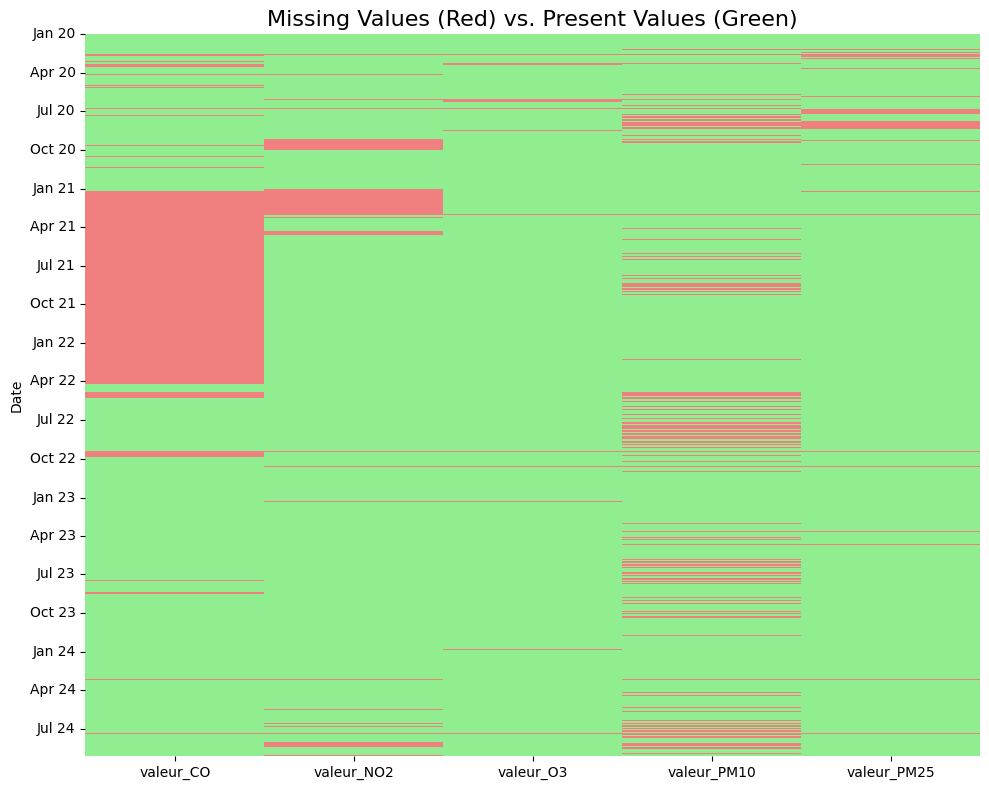

In [15]:
from matplotlib.colors import ListedColormap

# --- Ticks and Labels Logic ---
# Find the positions and labels for every third month
tick_positions = []
tick_labels = []
last_month_year = None # Helper to avoid duplicate month labels

for i, timestamp in enumerate(df.index):
    # Check for the first month of a quarter (Jan, Apr, Jul, Oct)
    if timestamp.month in [1, 4, 7, 10]:
        current_month_year = (timestamp.month, timestamp.year)
        # Add a tick only when the month changes to avoid multiple labels for the same month
        if current_month_year != last_month_year:
            tick_positions.append(i)
            tick_labels.append(timestamp.strftime('%b %y'))
            last_month_year = current_month_year

cmap = ListedColormap(['lightgreen', 'lightcoral'])

# Create the plot and get the axes object
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[pollutant_columns].isnull(), cmap=cmap, cbar=False, ax=ax)

# Set the custom ticks and labels on the y-axis
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, rotation=0) # rotation=0 keeps labels horizontal

ax.set_title('Missing Values (Red) vs. Present Values (Green)', fontsize=16)
ax.set_ylabel('Date')
plt.tight_layout() # Adjust plot to prevent labels from overlapping
plt.show()

With the white spots representing missing values, we can see that for some columns there are often long time intervals of multiple months when no data is available (especially for Carbon Monoxide data column between January 2021 and April 2022) therefore we will use a more thoughtout approach, adapted for each column separately.

In [16]:
column_means = df[pollutant_columns].mean()
print(column_means)

valeur_CO       0.200710
valeur_NO2     21.831528
valeur_O3      50.574349
valeur_PM10    18.221523
valeur_PM25    11.051161
dtype: float64


We can see that the average value differs per column. With CO having the lowest average value. In some way, this might mean that since our model is judged on MAE (Mean Absolute Error) that an error in CO is much less important that one in the others (especially in O3, where the average value is the highest)

In [17]:
correlation_matrix = df[pollutant_columns].corr()
print(correlation_matrix)

             valeur_CO  valeur_NO2  valeur_O3  valeur_PM10  valeur_PM25
valeur_CO     1.000000    0.707436  -0.482845     0.531823     0.627073
valeur_NO2    0.707436    1.000000  -0.641281     0.509953     0.520438
valeur_O3    -0.482845   -0.641281   1.000000    -0.208749    -0.296609
valeur_PM10   0.531823    0.509953  -0.208749     1.000000     0.887796
valeur_PM25   0.627073    0.520438  -0.296609     0.887796     1.000000


We can see high correlation between columns in our dataset, this makes sense since they are all tied to air pollution. Especially high is the correlation between `valeur_PM10` and `valeur_PM25`

### Imputation Strategy for Missing Pollutant Data

Our approach is a robust two-stage process designed to handle each column's specific missing data problem effectively while leveraging the relationships between the pollutants.

1.  `valeur_O3`

    This column has the fewest missing values. We will impute it first using simple Time-Based Linear Interpolation. This method draws a straight line between the known data points before and after a gap, which is a safe and effective approach for small, scattered gaps. By fixing O3 first, we create a fully complete and reliable feature to help impute the other columns.

2.  `valeur_CO`, `valeur_NO2`, `valeur_PM10`, `valeur_PM25`

    These columns have much larger and more complex patterns of missing data. We will handle them simultaneously using qolmat's powerful ImputerRegressor.

What is **ImputerRegressor** and How Does it Work?

*ImputerRegressor* is a multivariate, model-based imputer. Instead of using a simple statistical rule, it trains a machine learning model to "predict" the missing values. Here's the process:

- Initial Guess: It starts by filling all NaNs with a simple value (e.g., the column mean).

- Iterative Prediction: The process then becomes iterative, cycling through the columns:

    - It picks a column to be a target (e.g., valeur_CO).

    - It uses all the other columns as features to train a regression model (like a Random Forest) on the rows where valeur_CO was not originally missing.

    - It then uses this trained model to re-predict the values in the valeur_CO gap. These new estimates are far more accurate than the initial mean.

- Refinement: It repeats this process for every other column (NO2, PM10, etc.). It then starts the cycle over again, but this time using the improved estimates from the previous round as features. This allows the imputed values to get progressively more accurate.

This method is ideal for our dataset because it can realistically fill the large gaps in CO and NO2 by learning from their daily and yearly cycles, and it automatically leverages the strong correlation between PM10 and PM25.

### Execution

In [ ]:
from qolmat.imputations.imputers import ImputerRegressor
from sklearn.ensemble import RandomForestRegressor


print("Missing values before imputation:")
print(df[['valeur_CO', 'valeur_NO2', 'valeur_O3', 'valeur_PM10', 'valeur_PM25']].isnull().sum())
print("-" * 30)

# --------------------------------------------------------------------------
# Stage 1: Impute 'valeur_O3' using pandas' native interpolation method
# --- THIS IS THE CORRECTED PART ---
# --------------------------------------------------------------------------
# This method is called directly on the Series and has access to the DatetimeIndex
df['valeur_O3'] = df['valeur_O3'].interpolate(method='time')


# --------------------------------------------------------------------------
# Stage 2: Impute remaining columns using the Regressor Imputer AND Time Features
# (This part remains the same as it's the correct approach for the complex gaps)
# --------------------------------------------------------------------------

# Define the columns that the imputer will learn from and impute
columns_for_imputer = [
    'valeur_CO', 'valeur_NO2', 'valeur_O3', 'valeur_PM10', 'valeur_PM25',
    'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend'
]

# Instantiate the imputer
imputer_regressor = ImputerRegressor(
    estimator=RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42),
    handler_nan='column'
)


# Select the data for imputation
data_for_imputation = df[columns_for_imputer]

# Fit and transform the data
imputed_data_array = imputer_regressor.fit_transform(data_for_imputation)

# Convert the resulting numpy array back to a DataFrame
imputed_df = pd.DataFrame(imputed_data_array, index=df.index, columns=columns_for_imputer)

# Securely update only the pollutant columns in the original DataFrame
pollutant_cols = ['valeur_CO', 'valeur_NO2', 'valeur_O3', 'valeur_PM10', 'valeur_PM25']
df[pollutant_cols] = imputed_df[pollutant_cols]


print("Missing values after final imputation:")
print(df[pollutant_cols].isnull().sum())
print("-" * 30)

Missing values before imputation:
valeur_CO      12529
valeur_NO2      3297
valeur_O3        693
valeur_PM10     7167
valeur_PM25     1791
dtype: int64
------------------------------


TypeError: ImputerRegressor.__init__() got an unexpected keyword argument 'model'